# Spotify Music Analysis

## Goal
Analyze how audio features affect song popularity.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load datadet

In [2]:
data_origin = pd.read_csv('data/spotify.csv')
data_origin.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Data Shape

In [3]:
data_origin.shape

(114000, 22)

## 3. Dataset Information
We inspect structure, data types and missing values.

In [4]:
data_origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

## 4. Missing Values

In [10]:
data_origin.isnull().sum().sort_values(ascending=False)

album_name          1
artists             1
track_name          1
Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## 5. Duplicate Records

In [11]:
data_origin.duplicated().sum()

np.int64(0)

## 6. Statistical Summary

In [13]:
data_origin.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965


## 7. Data Clean 

In [14]:
data = data_origin.drop_duplicates()
data = data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
data = data.dropna()
data.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 8. Distribution of Popularity

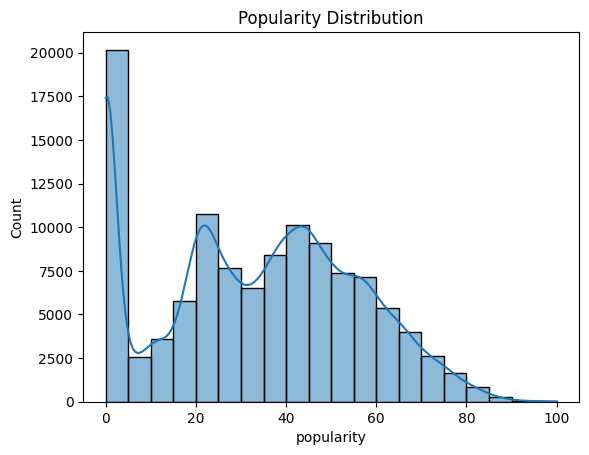

In [20]:
plt.figure()
sns.histplot(data['popularity'],bins=20, kde=True)
plt.title("Popularity Distribution")
plt.show()

## 9. Top Genres

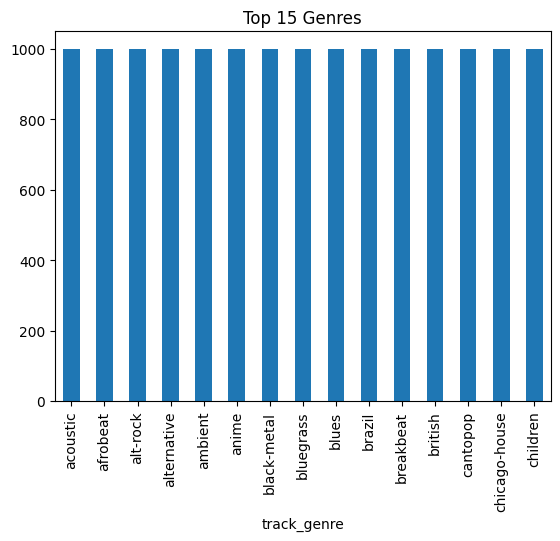

In [ ]:
plt.figure()
data['track_genre'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Genres")
plt.show()

## 10. Audio Feature Distribution

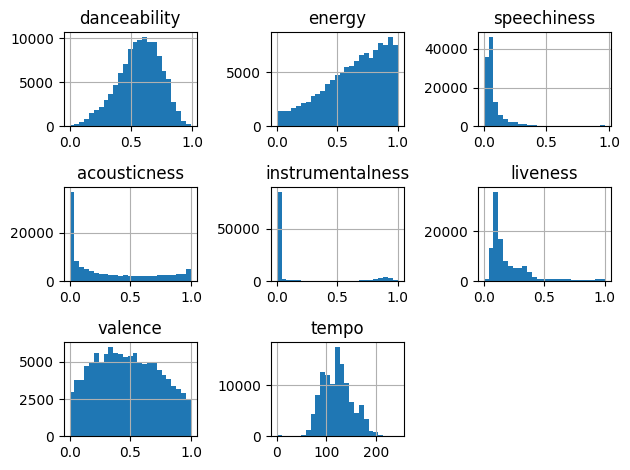

In [25]:
audio_features = ['danceability','energy','speechiness','acousticness', 'instrumentalness','liveness','valence','tempo']
data[audio_features].hist(bins=25)
plt.tight_layout()

## 11. Correlation Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

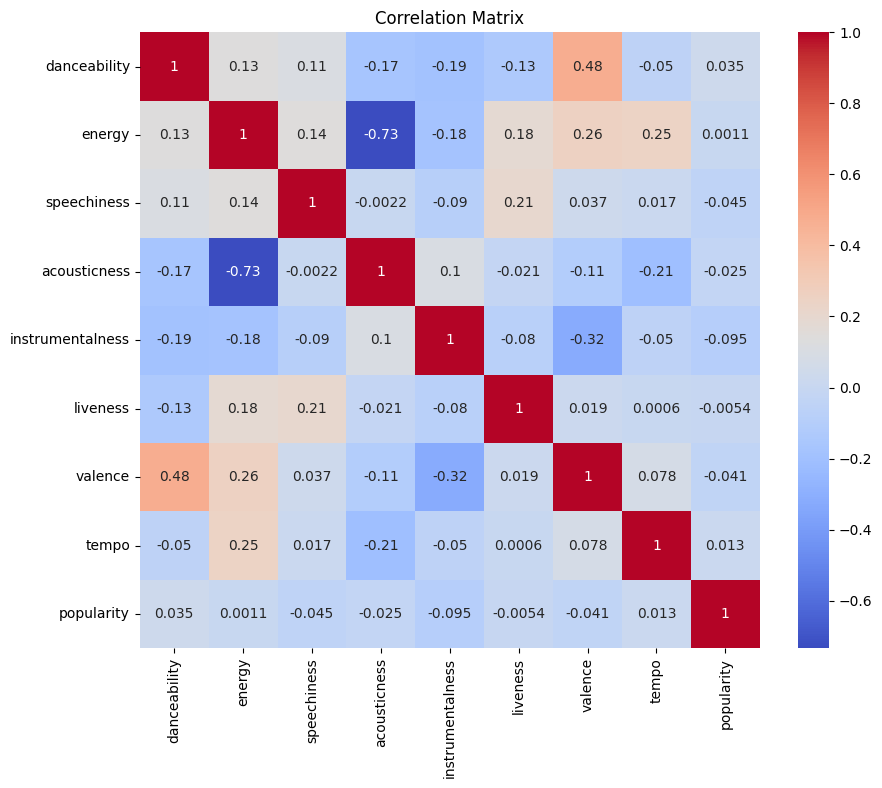

In [30]:
plt.figure(figsize=(10,8))
corr = data[audio_features + ['popularity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

## 12. Dance vs Energy

Text(0.5, 1.0, 'Danceability vs Energy')

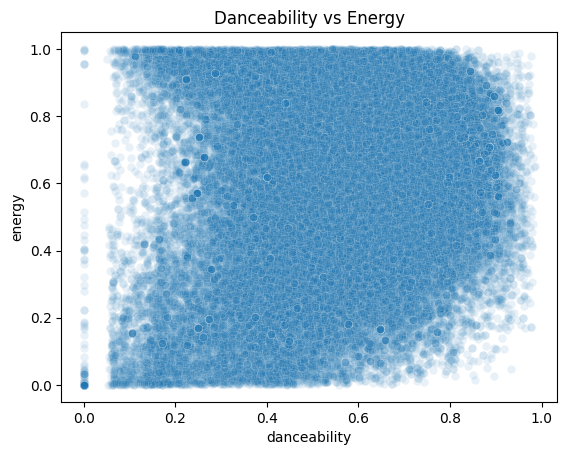

In [32]:
plt.figure()
sns.scatterplot(data=data, x='danceability', y='energy', alpha=0.1)
plt.title("Danceability vs Energy")

## 13. Genre-wise Average Audio Features

In [33]:
genre_group = data.groupby('track_genre')[audio_features].mean()
genre_group.head()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,
acoustic,0.549593,0.435368,0.043247,0.566816,0.038336,0.153244,0.424023,119.010624
afrobeat,0.669580,0.702812,0.086579,0.270860,0.253483,0.184596,0.698619,119.213337
alt-rock,0.534493,0.754173,0.055071,0.122162,0.054097,0.210249,0.518260,124.634404
alternative,0.559927,0.720030,0.070101,0.147820,0.038159,0.201376,0.495570,122.232394
ambient,0.367867,0.237162,0.041562,0.776790,0.676221,0.129283,0.167498,111.113129


## 14. Genres comparision

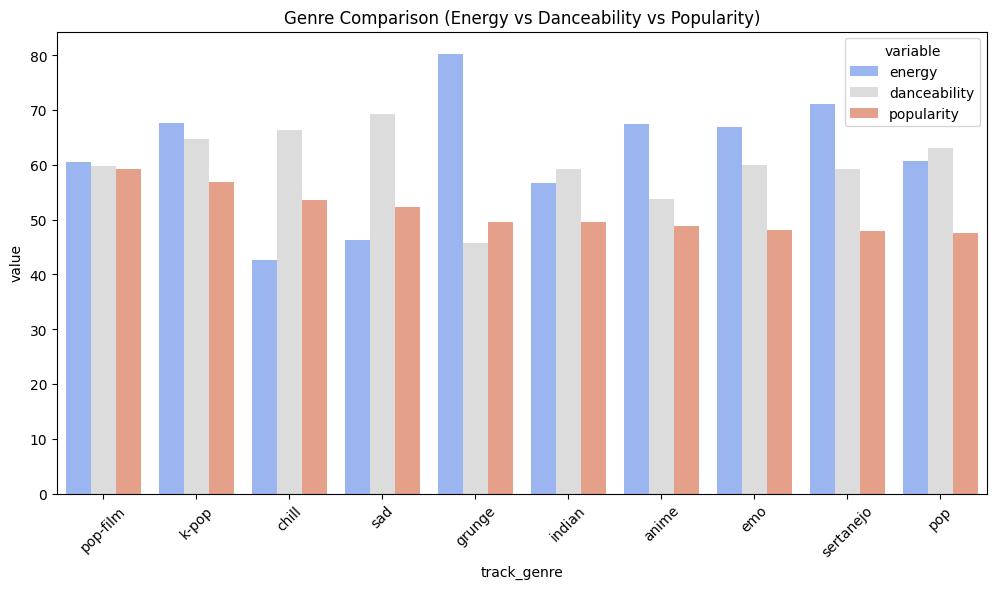

In [37]:
genre_stats= data.groupby('track_genre')[['energy','danceability','popularity']].mean().reset_index()
genre_stats[['energy','danceability']] *= 100
top = genre_stats.sort_values('popularity', ascending=False).head(10)

top = genre_stats.sort_values('popularity', ascending=False).head(10)

top_melted = top.melt(id_vars='track_genre',
                       value_vars=['energy','danceability','popularity'])

plt.figure(figsize=(12,6))
sns.barplot(data=top_melted, x='track_genre', y='value', hue='variable', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Genre Comparison (Energy vs Danceability vs Popularity)')
plt.show()


## 15. Preparing data for learning model

In [36]:
X = data[audio_features]
Y = data['track_genre']
X.head()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,0.0526,0.4690,0.000000,0.0829,0.167,119.949
